In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df =pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.shape

(10000, 14)

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.describe(include = 'object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [13]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)

In [14]:
df.shape

(10000, 11)

In [15]:
df = pd.get_dummies(df, columns = ['Geography'], drop_first = True)

In [16]:
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 2})

In [17]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,False,True


In [18]:
X = df.drop('Exited', axis =1)
y = df['Exited']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 130626)

In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
smote = SMOTE(random_state = 130626)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=130626)
lr.fit(X_train_scaled, y_train_smote)

LogisticRegression(max_iter=1000, random_state=130626)

In [28]:
y_pred_lr = lr.predict(X_test_scaled)

In [29]:
print(confusion_matrix(y_test, y_pred_lr))

[[1263  333]
 [ 186  218]]


In [30]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1596
           1       0.40      0.54      0.46       404

    accuracy                           0.74      2000
   macro avg       0.63      0.67      0.64      2000
weighted avg       0.78      0.74      0.75      2000



In [31]:
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('f1 score:', f1_score(y_test, y_pred_lr))
print('Recall score:', recall_score(y_test, y_pred_lr))

Accuracy: 0.7405
f1 score: 0.45654450261780105
Recall score: 0.5396039603960396


In [32]:
dt = DecisionTreeClassifier(max_depth=5, random_state=130626)
dt.fit(X_train_scaled, y_train_smote)

DecisionTreeClassifier(max_depth=5, random_state=130626)

In [33]:
y_pred_dt = dt.predict(X_test_scaled)

In [34]:
print(confusion_matrix(y_test, y_pred_dt))

[[1296  300]
 [ 154  250]]


In [35]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1596
           1       0.45      0.62      0.52       404

    accuracy                           0.77      2000
   macro avg       0.67      0.72      0.69      2000
weighted avg       0.81      0.77      0.78      2000



In [36]:
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('f1 score:', f1_score(y_test, y_pred_dt))
print('Recall score:', recall_score(y_test, y_pred_dt))

Accuracy: 0.773
f1 score: 0.5241090146750524
Recall score: 0.6188118811881188


In [37]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_smote)

RandomForestClassifier(random_state=42)

In [38]:
y_pred_rf = rf.predict(X_test_scaled)

In [39]:
print(confusion_matrix(y_test, y_pred_rf))

[[1401  195]
 [ 156  248]]


In [40]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1596
           1       0.56      0.61      0.59       404

    accuracy                           0.82      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.82      0.83      2000



In [41]:
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('f1 score:', f1_score(y_test, y_pred_rf))
print('Recall score:', recall_score(y_test, y_pred_rf))

Accuracy: 0.8245
f1 score: 0.5855962219598583
Recall score: 0.6138613861386139


In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [43]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train_smote)

KNeighborsClassifier()

In [44]:
y_pred_knn = knn.predict(X_test_scaled)

In [45]:
print(confusion_matrix(y_test, y_pred_knn))

[[1330  266]
 [ 166  238]]


In [46]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1596
           1       0.47      0.59      0.52       404

    accuracy                           0.78      2000
   macro avg       0.68      0.71      0.69      2000
weighted avg       0.80      0.78      0.79      2000



In [47]:
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
print('f1 score:', f1_score(y_test, y_pred_knn))
print('Recall score:', recall_score(y_test, y_pred_knn))

Accuracy: 0.784
f1 score: 0.5242290748898678
Recall score: 0.5891089108910891


In [48]:
from xgboost import XGBClassifier

In [49]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [50]:
y_pred_xgb = xgb.predict(X_test_scaled)

In [51]:
print(confusion_matrix(y_test, y_pred_xgb))

[[1395  201]
 [ 166  238]]


In [52]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1596
           1       0.54      0.59      0.56       404

    accuracy                           0.82      2000
   macro avg       0.72      0.73      0.72      2000
weighted avg       0.82      0.82      0.82      2000



In [53]:
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('f1 score:', f1_score(y_test, y_pred_xgb))
print('Recall score:', recall_score(y_test, y_pred_xgb))

Accuracy: 0.8165
f1 score: 0.564650059311981
Recall score: 0.5891089108910891


In [54]:
importances = xgb.feature_importances_

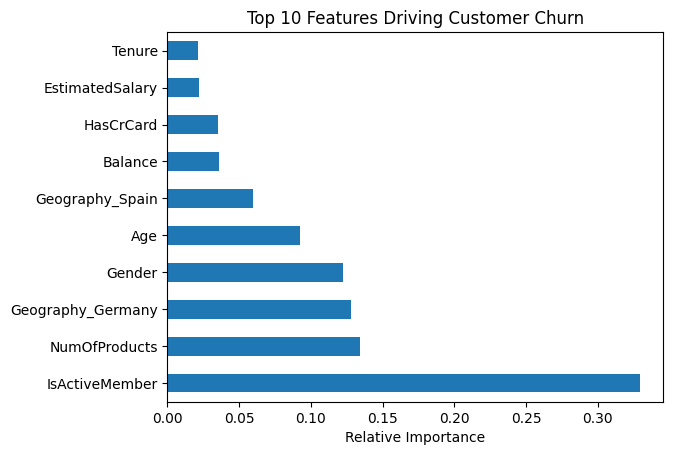

In [55]:
feature_names = X_train_smote.columns if hasattr(X_train_smote, 'columns') else [f"Feature {i}" for i in range(X_train_scaled.shape[1])]

feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features Driving Customer Churn')
plt.xlabel('Relative Importance')
plt.show()